# GeoPark Betsy Gun vs Hammer Source Comparison

This notebook is a focused source-characterization notebook for the USF GeoPark active-source experiment.
It compares one Betsy seisgun shot with two representative hammer blows using:

- time-domain waveform overlays,
- amplitude spectra,
- optional differentiated traces, useful if the raw SmartSolo data are velocity and we want acceleration-like source signatures,
- station/component-by-station/component comparison plots,
- summary figures for the closest node and for all traces.

This notebook intentionally omits event detection, picker testing, consensus picks, and SEG-Y export. Those belong in the separate event-processing notebook.


## 1. Imports and configuration

Set `geopark_data_path` to the folder containing `geopark_all.mseed`. The default path matches the working path used in the original notebook.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import obspy
from scipy.signal import welch

plt.rcParams["figure.dpi"] = 120

# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------
geopark_data_path = Path(
    "/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark"
)

mseed_file = geopark_data_path / "geopark_all.mseed"

# Reference time used in the field notes/original notebook.
reference_time = obspy.UTCDateTime(2026, 4, 30, 18, 29, 30)

# Time windows are seconds relative to reference_time.
# These can be adjusted after visual inspection.
source_windows = {
    "Betsy gun": (36.5, 37.5),
    "Hammer 1": (562.1, 563.1),
    "Hammer 2": (658.42, 659.42),
}

# Optional node serial -> clean station names.
station_lookup = {
    "13322": "node1",
    "13396": "node2",
    "12683": "node3",
    "13783": "node4",
    "20406": "node5",
    "13851": "node6",
}

# Node spacing along the N-S line. This is included for labels/QC only here.
node_spacing_m = 2.0

# Output folder for figures and tables.
outdir = Path("GeoPark_source_comparison")
outdir.mkdir(exist_ok=True)

mseed_file


PosixPath('/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/GeoPark/geopark_all.mseed')

## 2. Utility functions


In [2]:
def rename_stations(st, lookup):
    """Return a copy of a Stream with station codes renamed using a lookup dictionary."""
    st_out = st.copy()
    for tr in st_out:
        if tr.stats.station in lookup:
            tr.stats.station = lookup[tr.stats.station]
    return st_out


def basic_preprocess(st, freqmin=None, freqmax=None, differentiate=False):
    """
    Return a lightly processed copy of a Stream.

    Parameters
    ----------
    st : obspy.Stream
        Input waveform stream.
    freqmin, freqmax : float or None
        Optional bandpass limits. If either is None, filtering is skipped.
    differentiate : bool
        If True, differentiate traces. This is useful if the input is velocity
        and we want an acceleration-like comparison.
    """
    st_out = st.copy()
    st_out.merge(method=1, fill_value="interpolate")
    st_out.detrend("demean")
    st_out.detrend("linear")
    st_out.taper(max_percentage=0.02)

    if freqmin is not None and freqmax is not None:
        st_out.filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=4, zerophase=True)

    if differentiate:
        st_out = st_out.differentiate()

    return st_out


def trim_windows_by_label(st, reference_time, windows):
    """
    Create labelled trimmed streams from a continuous Stream.

    Parameters
    ----------
    st : obspy.Stream
        Continuous data.
    reference_time : obspy.UTCDateTime
        Reference time for relative offsets.
    windows : dict
        Mapping from label -> (start_offset_s, end_offset_s).

    Returns
    -------
    dict[str, obspy.Stream]
        Labelled event/source windows.
    """
    labelled = {}
    for label, (t0, t1) in windows.items():
        labelled[label] = st.copy().trim(
            starttime=reference_time + float(t0),
            endtime=reference_time + float(t1),
            pad=False,
        )
    return labelled


def amplitude_spectrum(tr, taper_fraction=0.05, normalize=False):
    """Return frequency and linear amplitude spectrum for one ObsPy Trace."""
    tr2 = tr.copy()
    tr2.detrend("demean")
    tr2.detrend("linear")
    tr2.taper(max_percentage=taper_fraction)

    data = tr2.data.astype(float)
    n = tr2.stats.npts
    dt = tr2.stats.delta

    freqs = np.fft.rfftfreq(n, d=dt)
    amps = np.abs(np.fft.rfft(data))

    if normalize and np.nanmax(amps) > 0:
        amps = amps / np.nanmax(amps)

    return freqs, amps


def welch_spectrum(tr, taper_fraction=0.05, nperseg=512, normalize=False):
    """Return Welch amplitude spectral density for one ObsPy Trace."""
    tr2 = tr.copy()
    tr2.detrend("demean")
    tr2.detrend("linear")
    tr2.taper(max_percentage=taper_fraction)
    data = tr2.data.astype(float)
    fs = tr2.stats.sampling_rate

    f, psd = welch(data, fs=fs, nperseg=min(nperseg, len(data)), detrend="constant")
    asd = np.sqrt(psd)

    if normalize and np.nanmax(asd) > 0:
        asd = asd / np.nanmax(asd)

    return f, asd


def stream_summary_table(st):
    """Return a compact table of trace IDs, sampling rates, and durations."""
    rows = []
    for tr in st:
        rows.append({
            "id": tr.id,
            "network": tr.stats.network,
            "station": tr.stats.station,
            "location": tr.stats.location,
            "channel": tr.stats.channel,
            "sampling_rate_hz": tr.stats.sampling_rate,
            "npts": tr.stats.npts,
            "starttime": str(tr.stats.starttime),
            "endtime": str(tr.stats.endtime),
            "duration_s": tr.stats.npts * tr.stats.delta,
        })
    return pd.DataFrame(rows)


In [3]:
def plot_overlay_for_trace_id(
    labelled_streams,
    seed_id,
    *,
    twin=None,
    taper_fraction=0.05,
    normalize_waveforms=False,
    normalize_spectra=False,
    fmin=0.0,
    fmax=250.0,
    use_welch=False,
    title_prefix="",
    outfile=None,
    dpi=180,
):
    """
    Plot waveform and spectrum overlays for one SEED id across labelled windows.

    Parameters
    ----------
    labelled_streams : dict[str, obspy.Stream]
        Label -> trimmed stream.
    seed_id : str
        Trace id to compare, e.g. 'SS.node1.SW.DPZ'.
    twin : tuple or None
        Optional time window relative to each source-window start. For example
        (0.35, 0.60) focuses on the main arrival in a 1-second source window.
    use_welch : bool
        If True, plot Welch ASD. Otherwise, plot FFT amplitude spectrum.
    outfile : str or Path or None
        If provided, save the figure.
    """
    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
    ax_wav, ax_spec = axes

    plotted_any = False

    for label, st_win in labelled_streams.items():
        traces = st_win.select(id=seed_id)
        if len(traces) == 0:
            print(f"No trace for {seed_id} in window {label}")
            continue

        tr = traces.copy().merge(method=1, fill_value="interpolate")[0]
        if tr.stats.npts < 2:
            print(f"Skipping {seed_id}, {label}: too few samples")
            continue

        tr_plot = tr.copy()
        tr_plot.detrend("demean")
        tr_plot.detrend("linear")

        if twin is not None:
            tr_plot.trim(
                starttime=tr.stats.starttime + float(twin[0]),
                endtime=tr.stats.starttime + float(twin[1]),
                pad=False,
            )

        data = tr_plot.data.astype(float)
        if normalize_waveforms and np.nanmax(np.abs(data)) > 0:
            data = data / np.nanmax(np.abs(data))

        t = np.arange(tr_plot.stats.npts) * tr_plot.stats.delta
        if twin is not None:
            t = t + float(twin[0])

        ax_wav.plot(t, data, lw=1.7, label=label)

        if use_welch:
            freqs, amps = welch_spectrum(tr, taper_fraction=taper_fraction, normalize=normalize_spectra)
            spec_title = "Welch amplitude spectral density"
        else:
            freqs, amps = amplitude_spectrum(tr, taper_fraction=taper_fraction, normalize=normalize_spectra)
            spec_title = "FFT amplitude spectrum"

        keep = freqs >= fmin
        if fmax is not None:
            keep &= freqs <= fmax

        ax_spec.plot(freqs[keep], amps[keep], lw=1.7, label=label)
        plotted_any = True

    if not plotted_any:
        plt.close(fig)
        return None

    ylabel = "Normalized amplitude" if normalize_waveforms else "Amplitude"
    ax_wav.set_ylabel(ylabel)
    ax_wav.set_title(f"{title_prefix}Waveform overlay: {seed_id}".strip())
    ax_wav.grid(True, alpha=0.3)
    ax_wav.legend()

    spec_ylabel = "Normalized spectrum" if normalize_spectra else "Amplitude"
    ax_spec.set_xlabel("Frequency [Hz]")
    ax_spec.set_ylabel(spec_ylabel)
    ax_spec.set_title(f"{spec_title}: {seed_id}")
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()

    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)

    return fig


def plot_overlays_for_all_trace_ids(
    st,
    labelled_streams,
    outdir,
    *,
    component_filter=None,
    twin=None,
    taper_fraction=0.05,
    normalize_waveforms=False,
    normalize_spectra=False,
    fmin=0.0,
    fmax=250.0,
    use_welch=False,
    dpi=180,
):
    """Create waveform/spectrum overlay figures for all matching trace IDs."""
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    seed_ids = sorted({tr.id for tr in st})
    if component_filter is not None:
        component_filter = component_filter.upper()
        seed_ids = [sid for sid in seed_ids if sid[-1].upper() == component_filter]

    figures = []
    for seed_id in seed_ids:
        safe_id = seed_id.replace(".", "_")
        outfile = outdir / f"source_overlay_{safe_id}.png"
        fig = plot_overlay_for_trace_id(
            labelled_streams,
            seed_id,
            twin=twin,
            taper_fraction=taper_fraction,
            normalize_waveforms=normalize_waveforms,
            normalize_spectra=normalize_spectra,
            fmin=fmin,
            fmax=fmax,
            use_welch=use_welch,
            outfile=outfile,
            dpi=dpi,
        )
        if fig is not None:
            figures.append(outfile)
            plt.close(fig)

    return figures


In [4]:
def plot_station_three_component_overlay(
    labelled_streams,
    station,
    *,
    components=("Z", "N", "E"),
    twin=None,
    normalize_waveforms=True,
    outfile=None,
    dpi=180,
):
    """
    Plot 3-component waveform overlays for one station.

    One panel per component. Each panel overlays Betsy/Hammer windows.
    """
    fig, axes = plt.subplots(len(components), 1, figsize=(12, 8), sharex=True)
    if len(components) == 1:
        axes = [axes]

    for ax, comp in zip(axes, components):
        plotted = False
        for label, st_win in labelled_streams.items():
            traces = st_win.select(station=station, component=comp)
            if len(traces) == 0:
                continue

            tr = traces.copy().merge(method=1, fill_value="interpolate")[0]
            tr2 = tr.copy()
            tr2.detrend("demean")
            tr2.detrend("linear")

            if twin is not None:
                tr2.trim(tr.stats.starttime + twin[0], tr.stats.starttime + twin[1], pad=False)

            y = tr2.data.astype(float)
            if normalize_waveforms and np.nanmax(np.abs(y)) > 0:
                y = y / np.nanmax(np.abs(y))

            t = np.arange(tr2.stats.npts) * tr2.stats.delta
            if twin is not None:
                t = t + twin[0]

            ax.plot(t, y, lw=1.5, label=label)
            plotted = True

        ax.set_ylabel(comp)
        ax.grid(True, alpha=0.3)
        if plotted:
            ax.legend(loc="upper right")

    axes[-1].set_xlabel("Time relative to source-window start [s]")
    fig.suptitle(f"Betsy vs hammer waveform comparison: {station}")
    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)

    return fig


def plot_station_component_spectra(
    labelled_streams,
    station,
    component="Z",
    *,
    normalize_spectra=True,
    fmin=0,
    fmax=250,
    outfile=None,
    dpi=180,
):
    """Plot amplitude spectra for Betsy/Hammer windows for one station/component."""
    fig, ax = plt.subplots(figsize=(10, 5))

    for label, st_win in labelled_streams.items():
        traces = st_win.select(station=station, component=component)
        if len(traces) == 0:
            continue
        tr = traces.copy().merge(method=1, fill_value="interpolate")[0]
        freqs, amps = amplitude_spectrum(tr, normalize=normalize_spectra)
        keep = (freqs >= fmin) & (freqs <= fmax)
        ax.plot(freqs[keep], amps[keep], lw=1.8, label=label)

    ax.set_title(f"Betsy vs hammer spectra: {station} component {component}")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Normalized amplitude" if normalize_spectra else "Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    if outfile:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=dpi)

    return fig


## 3. Load the continuous GeoPark MiniSEED file

This cell reads the continuous MiniSEED file, merges traces, and renames SmartSolo serial-number station codes to `node1` ... `node6`.


In [5]:
st_raw = obspy.read(str(mseed_file))
st_raw.merge(method=1, fill_value="interpolate")
st_raw = rename_stations(st_raw, station_lookup)

summary = stream_summary_table(st_raw)
summary.to_csv(outdir / "geopark_stream_summary.csv", index=False)
summary


,id,network,station,location,channel,sampling_rate_hz,npts,starttime,endtime,duration_s
0,SS.node3.SW.DPE,SS,node3,SW,DPE,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
1,SS.node3.SW.DPN,SS,node3,SW,DPN,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
2,SS.node3.SW.DPZ,SS,node3,SW,DPZ,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
3,SS.node1.SW.DPE,SS,node1,SW,DPE,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
4,SS.node1.SW.DPN,SS,node1,SW,DPN,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
5,SS.node1.SW.DPZ,SS,node1,SW,DPZ,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
6,SS.node2.SW.DPE,SS,node2,SW,DPE,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
7,SS.node2.SW.DPN,SS,node2,SW,DPN,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
8,SS.node2.SW.DPZ,SS,node2,SW,DPZ,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002
9,SS.node4.SW.DPE,SS,node4,SW,DPE,500.0,1065001,2026-04-30T18:29:30.000000Z,2026-04-30T19:05:00.000000Z,2130.002


## 4. Define Betsy and hammer windows

The windows below are the same as the original exploratory notebook, expressed as seconds relative to `reference_time`.


In [6]:
source_windows


{'Betsy gun': (36.5, 37.5),
 'Hammer 1': (562.1, 563.1),
 'Hammer 2': (658.42, 659.42)}

In [7]:
# Raw velocity-like stream windows.
labelled_raw = trim_windows_by_label(st_raw, reference_time, source_windows)

# Differentiated stream windows. This is often useful if the raw SmartSolo data
# are velocity and we want an acceleration-like source signature.
st_diff = basic_preprocess(st_raw, differentiate=True)
labelled_diff = trim_windows_by_label(st_diff, reference_time, source_windows)

for label, st_win in labelled_raw.items():
    print(label)
    print(st_win)


Betsy gun
18 Trace(s) in Stream:
SS.node3.SW.DPE | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node3.SW.DPN | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node3.SW.DPZ | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node1.SW.DPE | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node1.SW.DPN | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node1.SW.DPZ | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node2.SW.DPE | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node2.SW.DPN | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node2.SW.DPZ | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07.500000Z | 500.0 Hz, 501 samples
SS.node4.SW.DPE | 2026-04-30T18:30:06.500000Z - 2026-04-30T18:30:07

## 5. Quick overview plots

These plots provide a quick sanity check before source comparison.


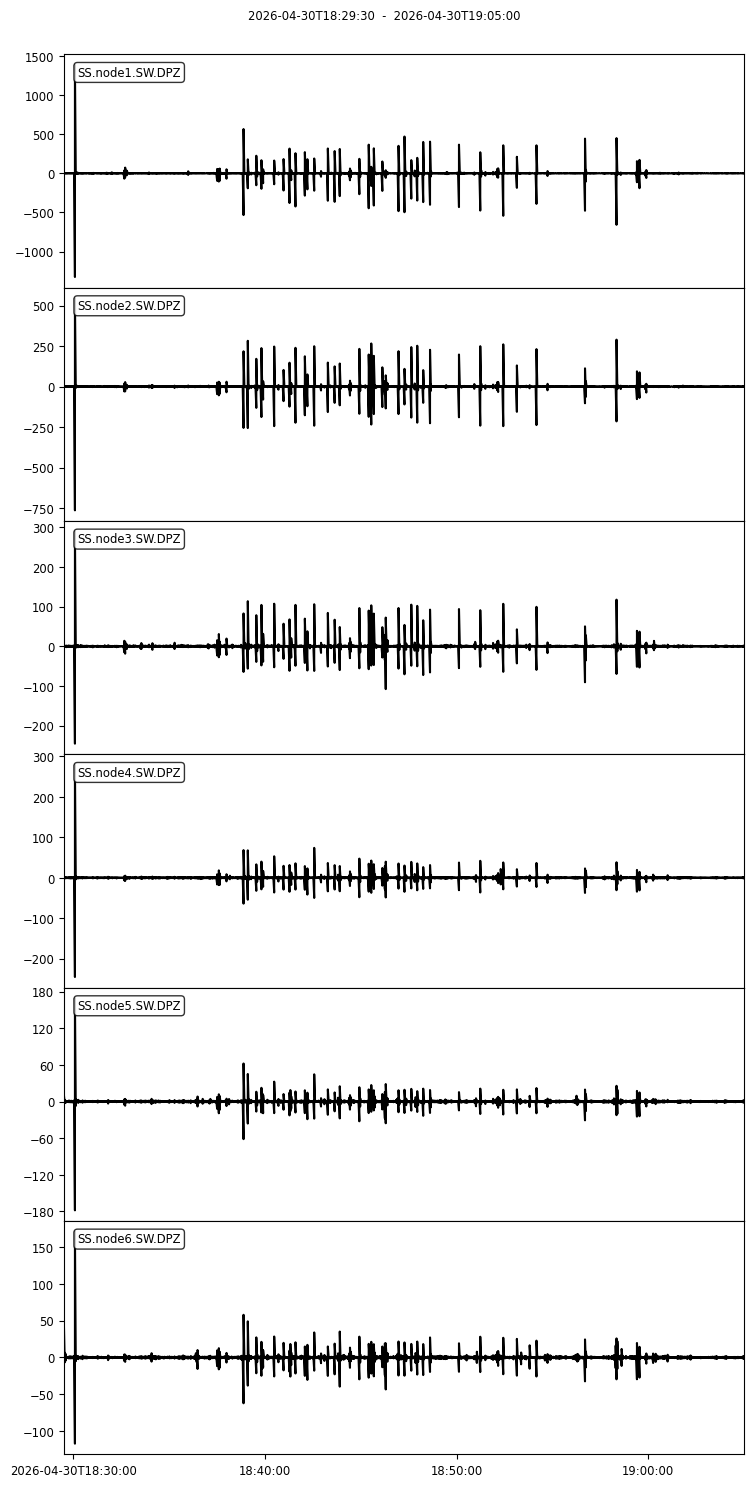

In [8]:
# Plot the full Z-component record in the notebook.
st_raw.select(component="Z").plot(equal_scale=False);


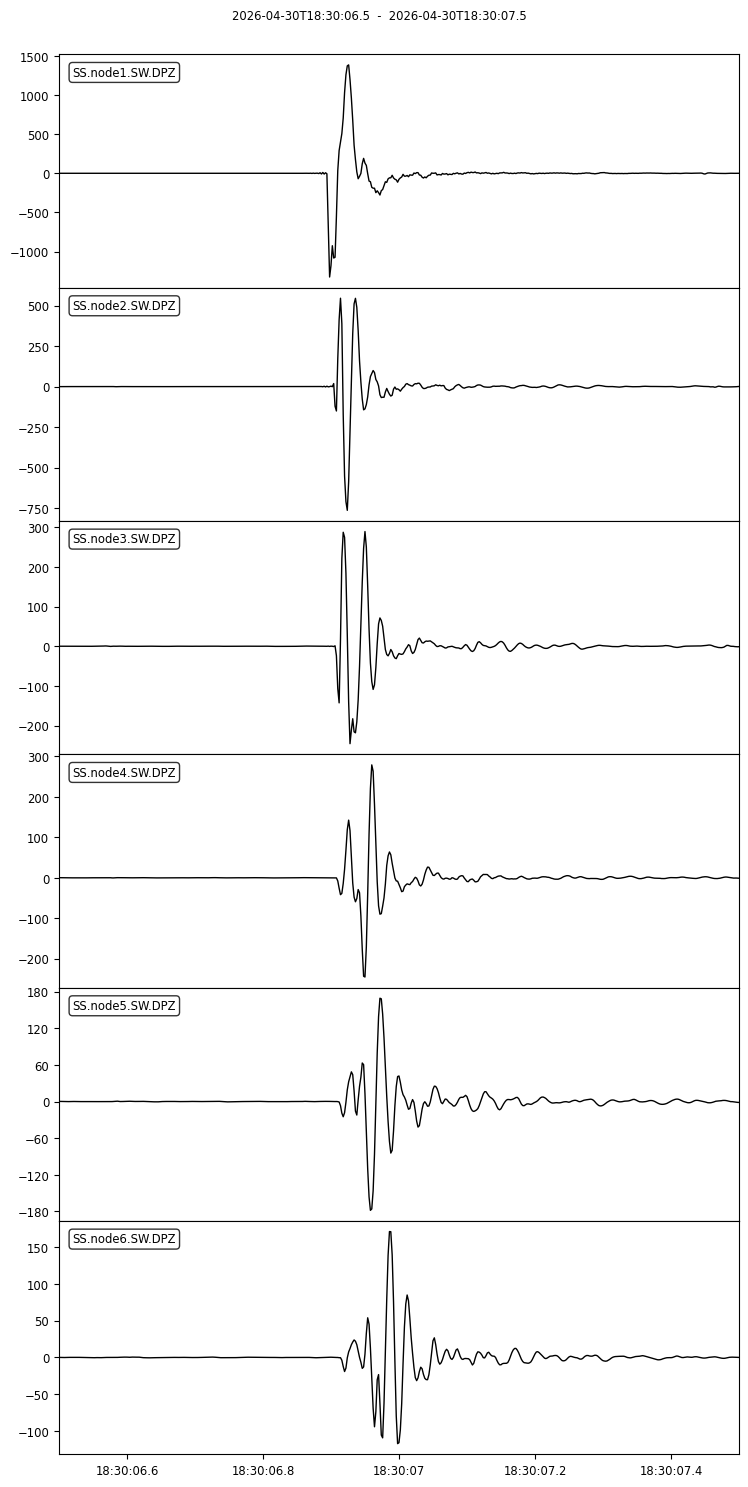

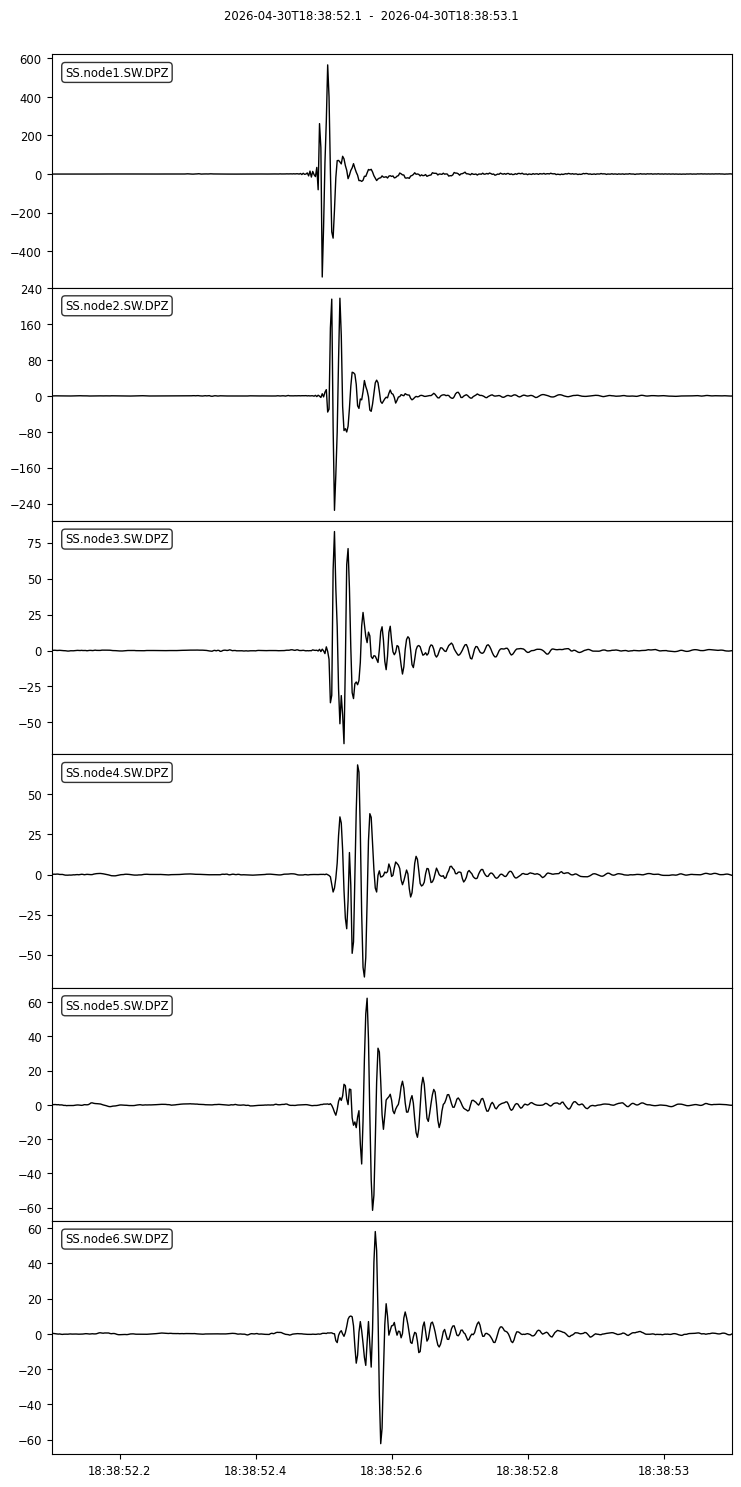

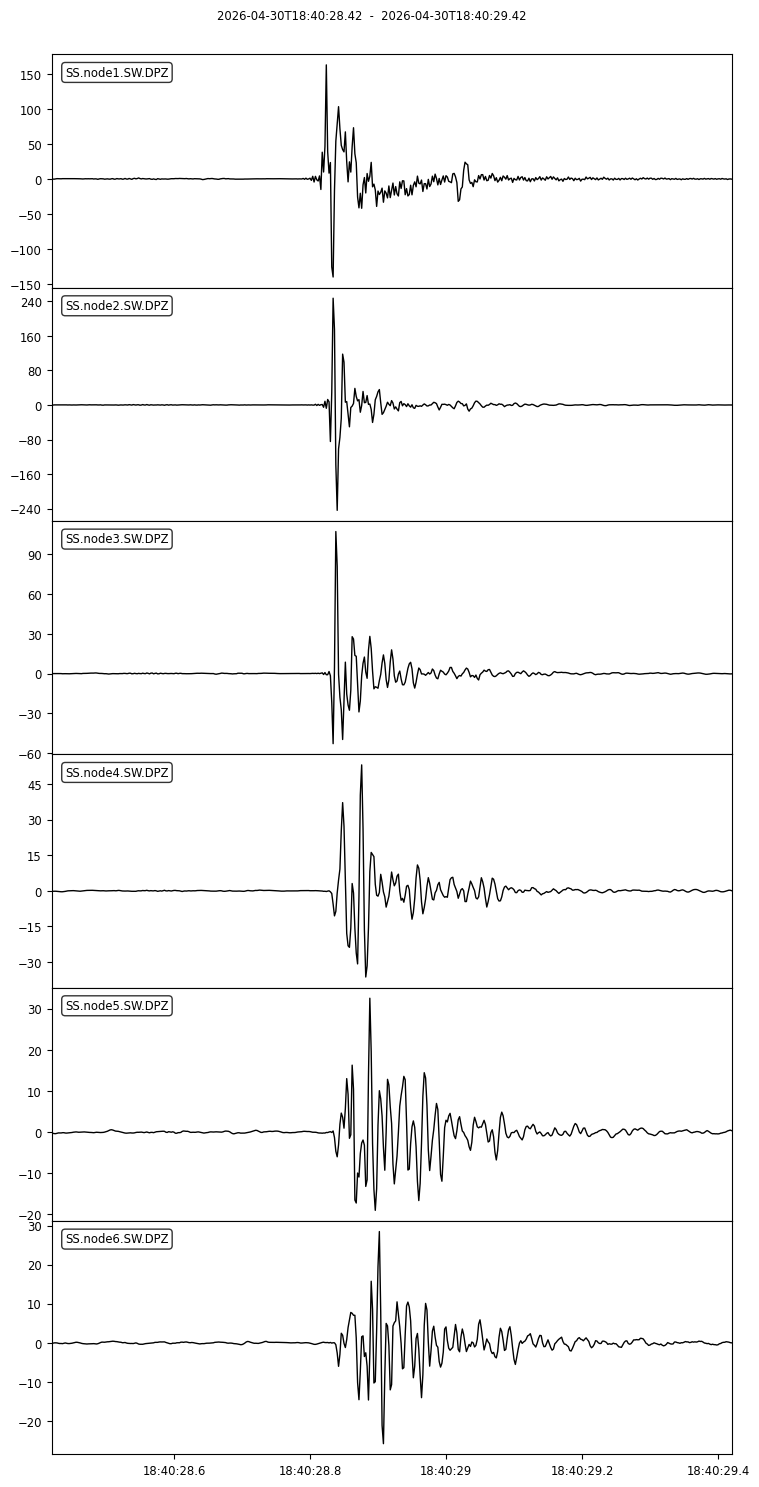

In [9]:
# Plot each source window, Z only, normalized by trace for visual comparison.
for label, st_win in labelled_raw.items():
    st_win.select(component="Z").plot(equal_scale=False, title=f"{label}: Z components");


## 6. Closest-node comparison

The original notebook used serial `13322`, now renamed to `node1`, as the closest Betsy node. This section compares Betsy and two hammer blows at that node.


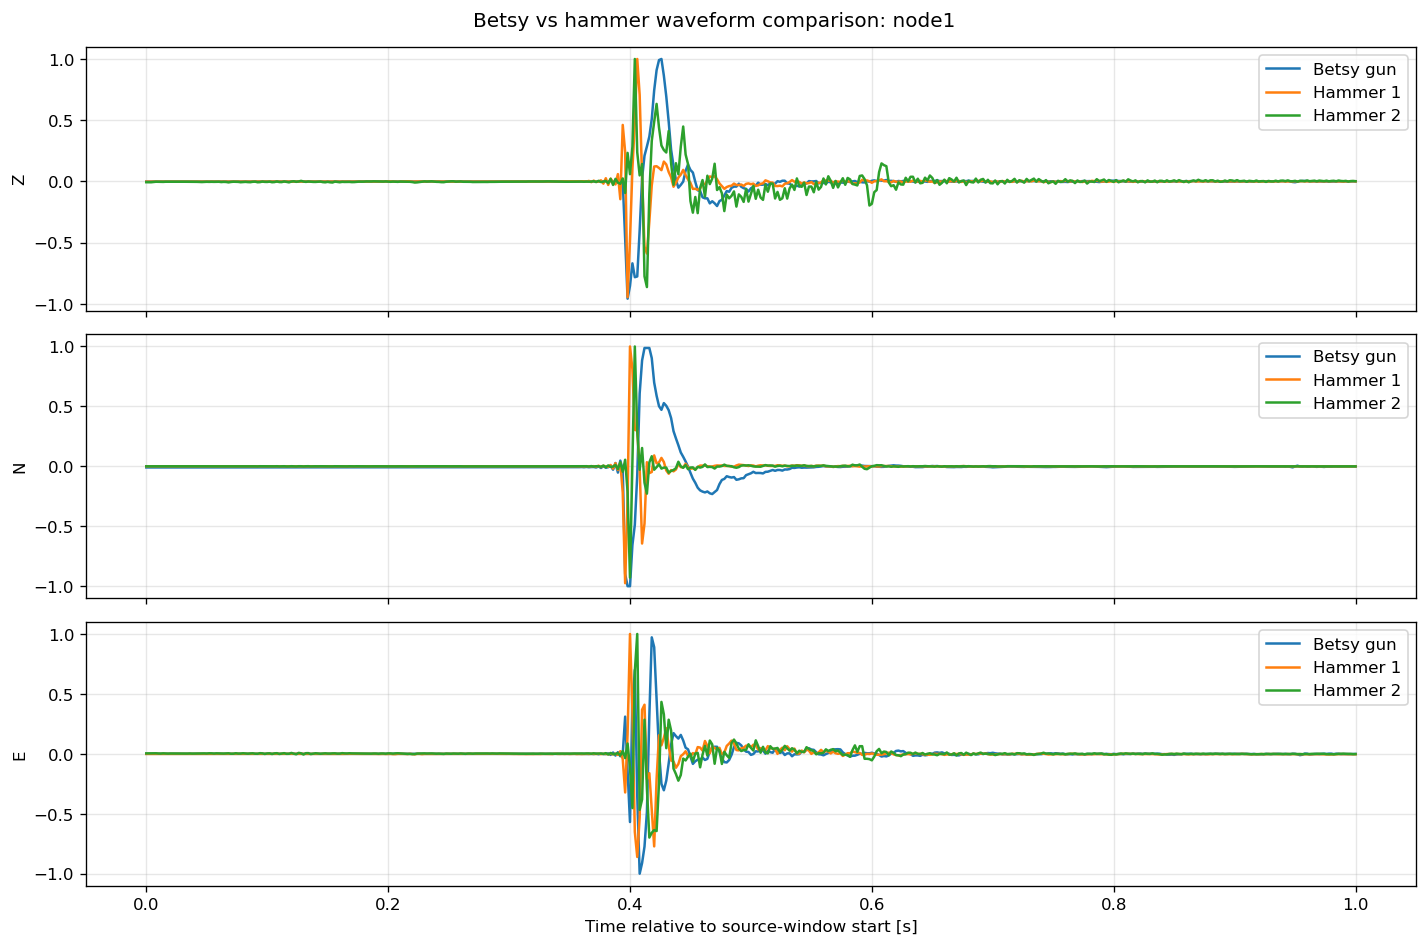

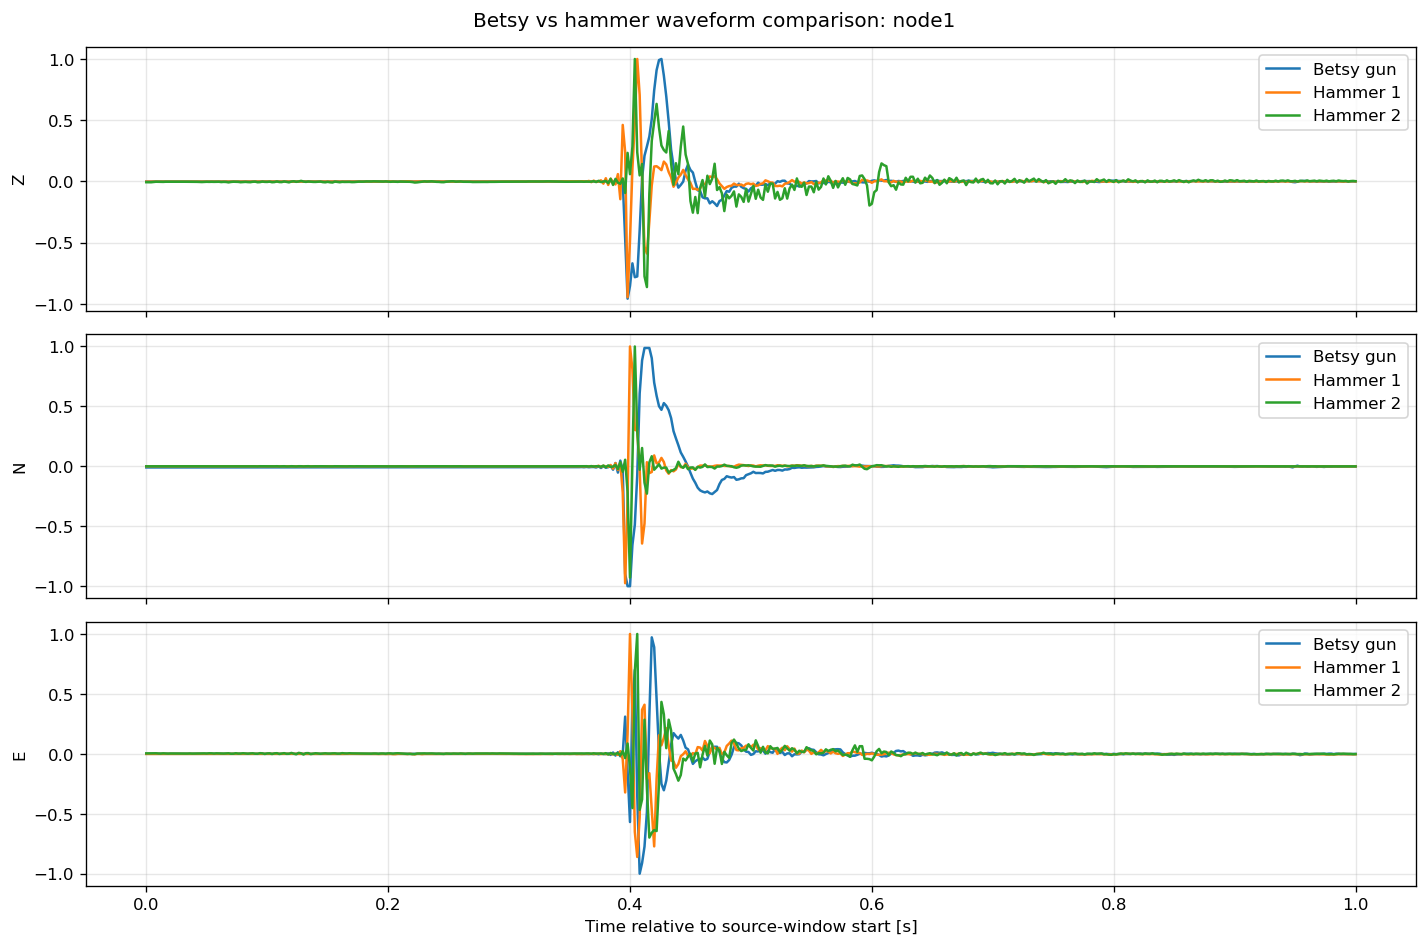

In [10]:
closest_station = "node1"

fig = plot_station_three_component_overlay(
    labelled_raw,
    closest_station,
    twin=None,
    normalize_waveforms=True,
    outfile=outdir / f"{closest_station}_three_component_waveform_overlay_raw.png",
)
fig


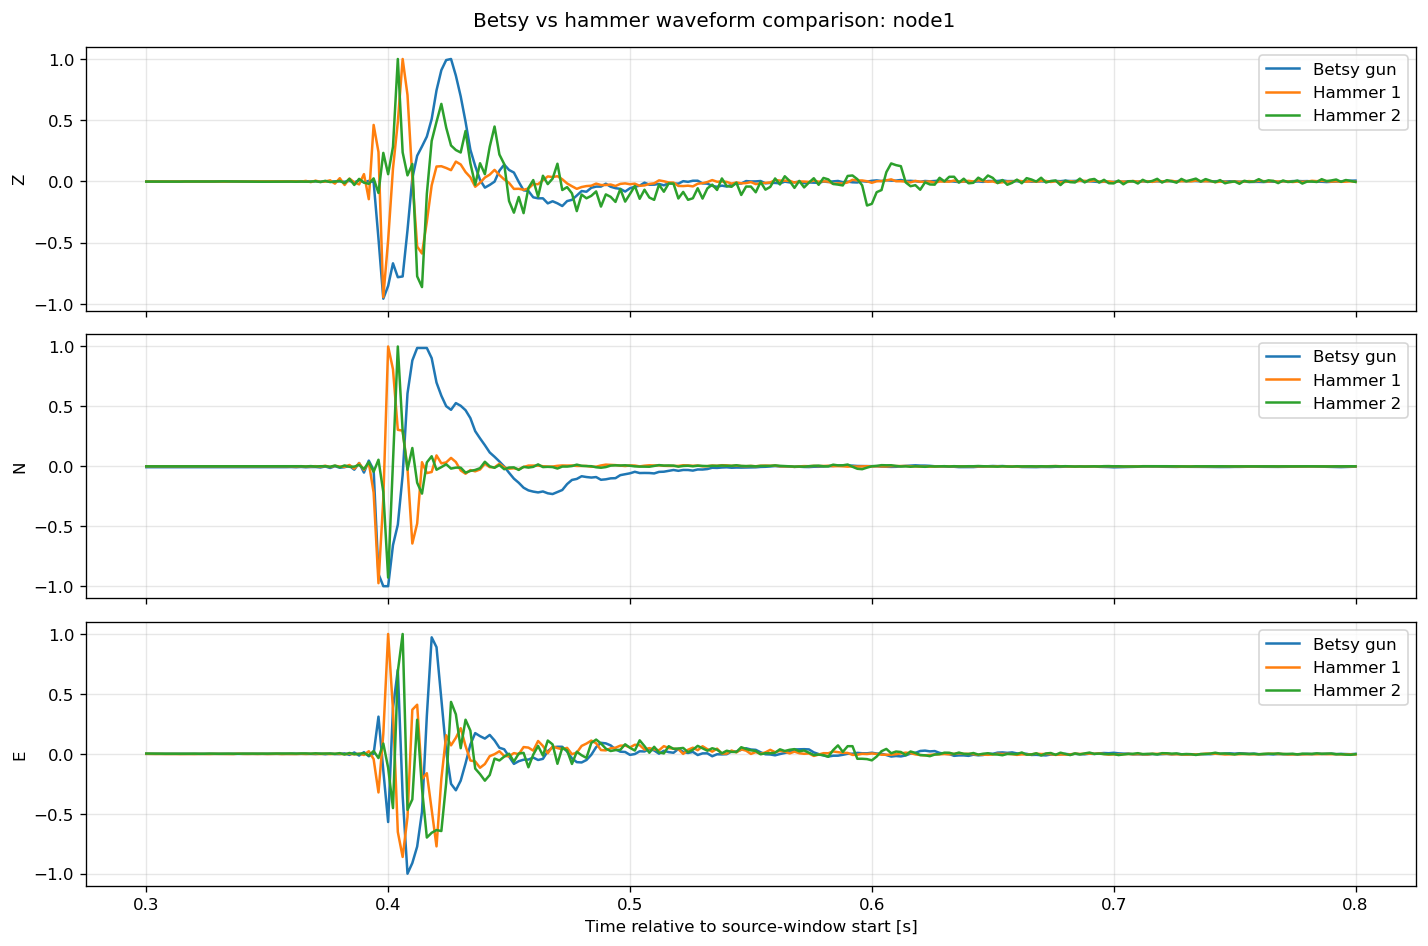

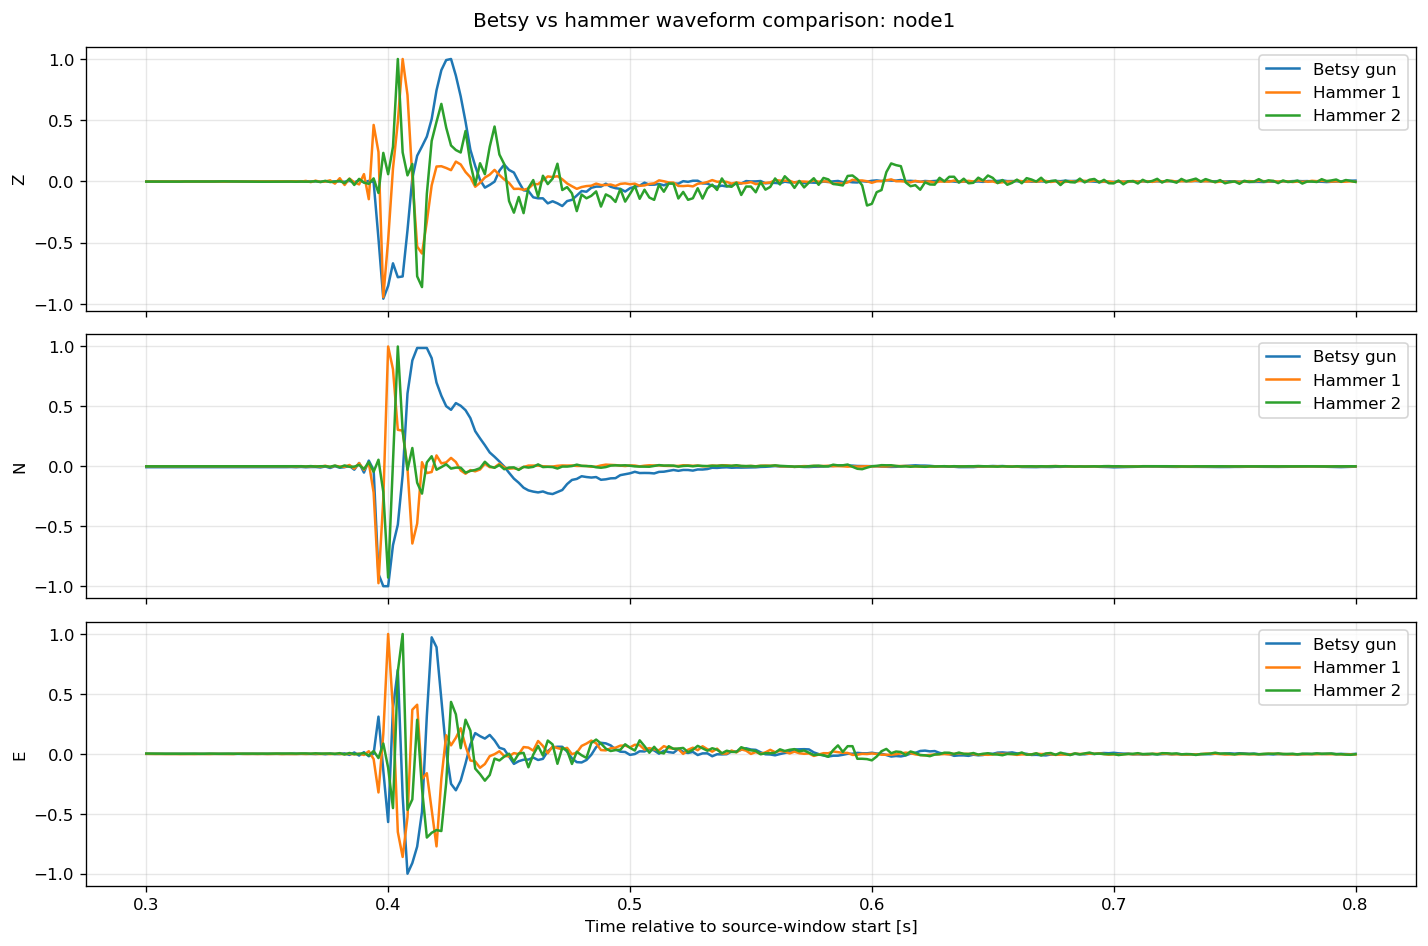

In [11]:
# Focus on the main arrival part of each 1-second window.
# Adjust twin if needed after inspecting the previous figure.
arrival_twin = (0.30, 0.80)

fig = plot_station_three_component_overlay(
    labelled_raw,
    closest_station,
    twin=arrival_twin,
    normalize_waveforms=True,
    outfile=outdir / f"{closest_station}_three_component_waveform_overlay_arrival_window.png",
)
fig


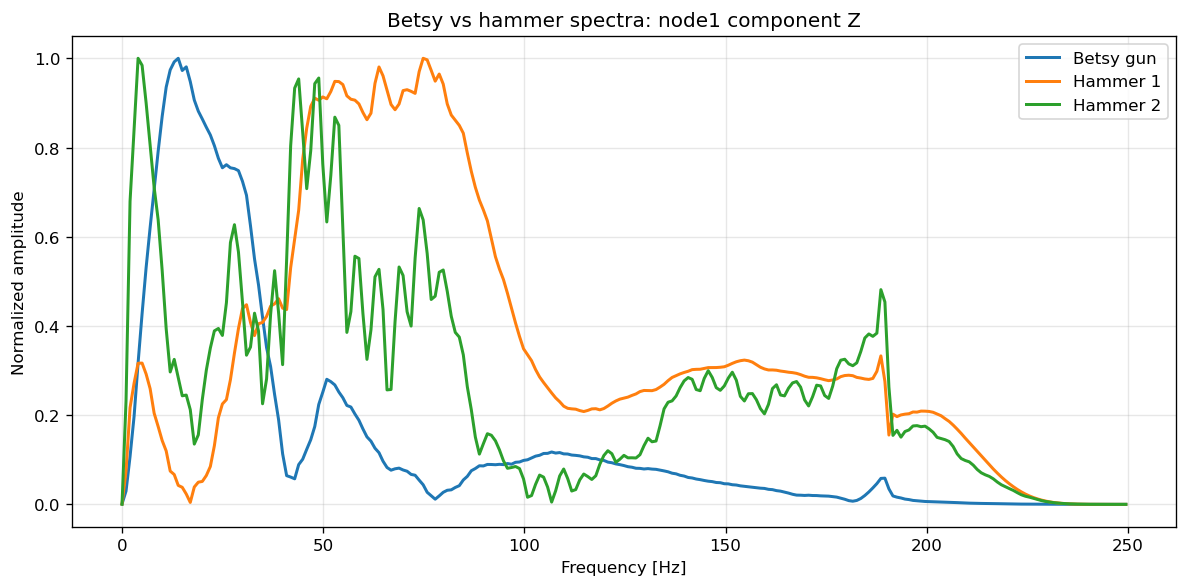

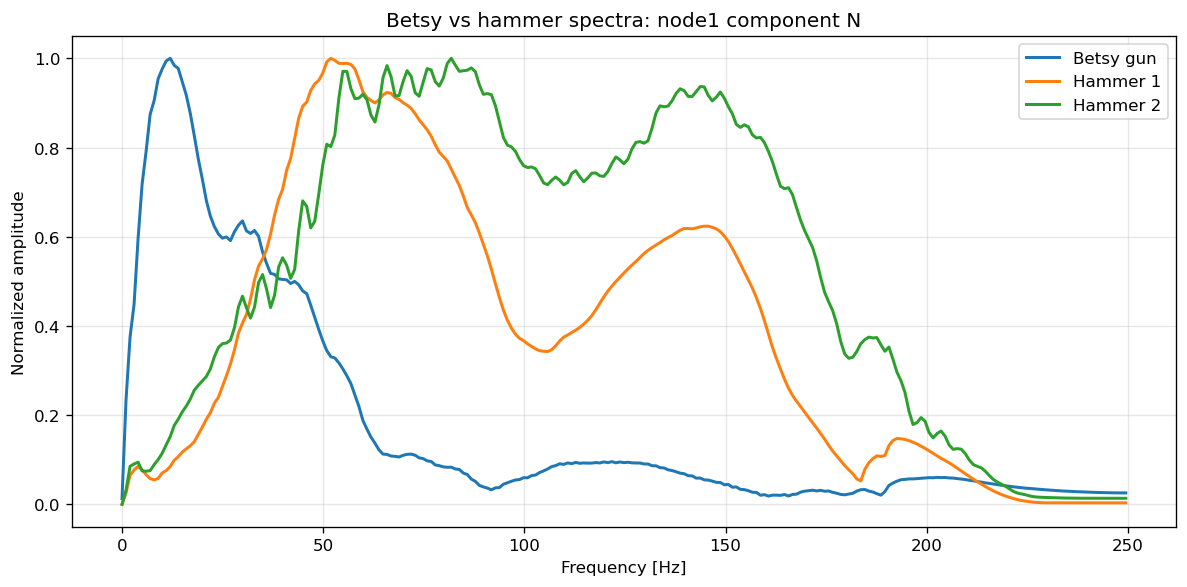

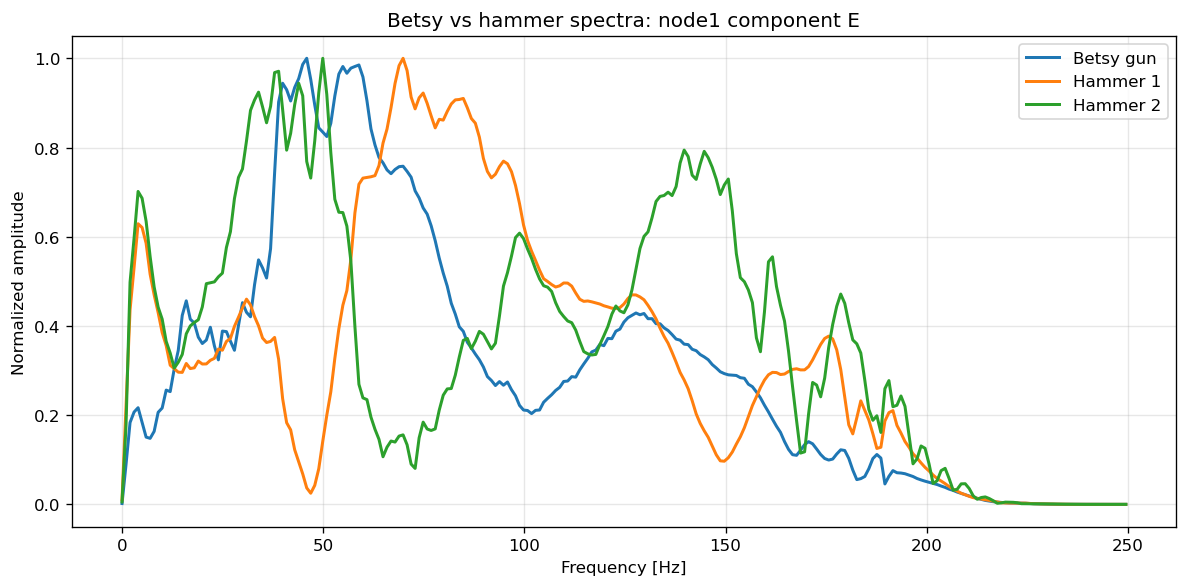

In [12]:
# Spectrum comparison at the closest node, component by component.
for component in ["Z", "N", "E"]:
    fig = plot_station_component_spectra(
        labelled_raw,
        closest_station,
        component=component,
        normalize_spectra=True,
        fmin=0,
        fmax=250,
        outfile=outdir / f"{closest_station}_{component}_normalized_spectra.png",
    )
    plt.show()


## 7. Per-trace waveform and spectrum overlays

This reproduces the most useful part of the original notebook: for every SEED id, overlay the Betsy gun, Hammer 1, and Hammer 2 waveforms and spectra.

By default this section uses differentiated data (`st_diff`) because the original notebook did that before plotting. Use `labelled_raw`/`st_raw` instead if you want the original units.


In [13]:
# Choose which labelled streams to use for the full per-trace comparison.
# labelled_raw  = raw MiniSEED after station renaming
# labelled_diff = differentiated traces
comparison_stream = st_diff
comparison_labelled_streams = labelled_diff

figures = plot_overlays_for_all_trace_ids(
    comparison_stream,
    comparison_labelled_streams,
    outdir / "per_trace_overlays_differentiated",
    component_filter=None,        # set to "Z" for Z only
    twin=(0.35, 0.60),            # focus on main arrival interval in each 1-s window
    taper_fraction=0.05,
    normalize_waveforms=False,
    normalize_spectra=False,
    fmin=0,
    fmax=250,
    use_welch=False,
)

print(f"Wrote {len(figures)} per-trace overlay figures")
figures[:5]


Wrote 18 per-trace overlay figures


[PosixPath('GeoPark_source_comparison/per_trace_overlays_differentiated/source_overlay_SS_node1_SW_DPE.png'),
 PosixPath('GeoPark_source_comparison/per_trace_overlays_differentiated/source_overlay_SS_node1_SW_DPN.png'),
 PosixPath('GeoPark_source_comparison/per_trace_overlays_differentiated/source_overlay_SS_node1_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/per_trace_overlays_differentiated/source_overlay_SS_node2_SW_DPE.png'),
 PosixPath('GeoPark_source_comparison/per_trace_overlays_differentiated/source_overlay_SS_node2_SW_DPN.png')]

## 8. Z-component summary across all nodes

This is a compact set of figures for the vertical component, which is probably the most relevant for first modelling comparisons.


In [14]:
z_figures = plot_overlays_for_all_trace_ids(
    st_raw,
    labelled_raw,
    outdir / "z_component_overlays_raw",
    component_filter="Z",
    twin=(0.30, 0.80),
    taper_fraction=0.05,
    normalize_waveforms=True,
    normalize_spectra=True,
    fmin=0,
    fmax=250,
    use_welch=False,
)

print(f"Wrote {len(z_figures)} Z-component overlay figures")
z_figures


Wrote 6 Z-component overlay figures


[PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node1_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node2_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node3_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node4_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node5_SW_DPZ.png'),
 PosixPath('GeoPark_source_comparison/z_component_overlays_raw/source_overlay_SS_node6_SW_DPZ.png')]

## 9. Optional: save individual spectra for each source window

This is useful if you want all individual trace spectra on disk, but it creates many files. Leave it disabled unless needed.


In [15]:
def save_stream_spectra(st, outdir, taper_fraction=0.05, nperseg=512):
    """
    Save FFT amplitude spectra and Welch ASD plots for every trace in a Stream.
    """
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    for tr in st:
        freqs, amps = amplitude_spectrum(tr, taper_fraction=taper_fraction, normalize=False)
        f_welch, asd = welch_spectrum(tr, taper_fraction=taper_fraction, nperseg=nperseg, normalize=False)

        safe_id = tr.id.replace(".", "_")
        start = tr.stats.starttime.strftime("%Y%m%dT%H%M%S")
        base = outdir / f"{safe_id}_{start}"

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(freqs, amps)
        ax.set_xlabel("Frequency [Hz]")
        ax.set_ylabel("Amplitude")
        ax.set_title(f"FFT amplitude spectrum: {tr.id}")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(f"{base}_fft_amplitude.png", dpi=180)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.loglog(f_welch[1:], asd[1:])
        ax.set_xlabel("Frequency [Hz]")
        ax.set_ylabel("Amplitude spectral density")
        ax.set_title(f"Welch ASD: {tr.id}")
        ax.grid(True, which="both", alpha=0.3)
        fig.tight_layout()
        fig.savefig(f"{base}_welch_asd.png", dpi=180)
        plt.close(fig)


# Uncomment to save individual spectra for each event window.
# for label, st_win in labelled_raw.items():
#     safe_label = label.lower().replace(" ", "_")
#     save_stream_spectra(st_win, outdir / "individual_spectra" / safe_label)


## 10. Notes for interpretation

Suggested interpretation checks:

1. Compare peak frequencies and high-frequency roll-off between Betsy and hammer sources.
2. Check whether the Betsy shot has more low-frequency energy but still comparable useful energy near 50–150 Hz.
3. Check whether hammer signals are more repeatable between Hammer 1 and Hammer 2.
4. Use the differentiated traces if the modelling source-time function is closer to force/acceleration than velocity.
5. Use the raw traces if the goal is direct comparison with SmartSolo recorded units.

The figures in `GeoPark_source_comparison/` can be used directly in emails or modelling notes for the SPECFEM/Deepwave source-time-function discussion.
